# Notebook 03 — Label Creation
### WID2003 Cognitive Science | FSKTM, Universiti Malaya

---

## Overview

Machine learning classifiers require a **target label** — a class we want to predict. This notebook derives a binary performance label for each participant based on their accuracy across all 8 visual search tasks. This label becomes the target variable (`y`) for all models.

**Inputs**
| File | Description |
|---|---|
| `data/raw/student_responses.csv` | Manually recorded response correctness per participant per task |
| `data/external/answer_key.json` | Confirmed correct AOI and task type for each stimulus |
| `data/processed/features_per_task.parquet` | Used to cross-check participant IDs |

**Output**
| File | Description |
|---|---|
| `data/processed/labels.csv` | One row per participant: accuracy score, performance label, speed label |

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain the **median split** method for creating binary labels and identify its strengths and weaknesses
2. Compute an **accuracy rate** from per-task binary response data
3. Recognise the **class imbalance** problem and explain why imbalanced classes can mislead classifier evaluation
4. Discuss the ethical implications of labelling students as "high" or "low" performing based on a single session

---

## Background

### Measuring Performance

Participants completed 8 visual search tasks. After each task, the observer recorded whether the participant found the correct answer:
- `1` = found the target correctly
- `0` = did not find the target
- blank = no response recorded

Each participant's **accuracy rate** = number of correct tasks ÷ 8.

### The Median Split

The **median split** divides participants at the midpoint of the accuracy distribution:

```
accuracy_rate >= median  →  High-performing  (Label = 1)
accuracy_rate <  median  →  Low-performing   (Label = 0)
```

This guarantees roughly balanced classes regardless of the score distribution. However, participants near the median are the hardest to classify correctly — a student who scores exactly at the median could plausibly belong to either group.

### Secondary Label: Speed

A `speed_label` (Fast / Slow) is derived from the mean `Time_to_first_fixation` on the `answer` AOI across all tasks — a gaze-derived measure of how quickly participants located the correct region.

### Student Responses File Format

`data/raw/student_responses.csv` must follow this schema:

| Column | Values |
|---|---|
| `participant_id` | Must match Tobii participant name exactly (lowercase) |
| `findDice_correct` | `1`, `0`, or blank |
| `findYummy_correct` | `1`, `0`, or blank |
| `frogInBathroom_correct` | `1`, `0`, or blank |
| `headphoneInBathroom_correct` | `1`, `0`, or blank |
| `frog_correct` | `1`, `0`, or blank |
| `whoCheats_correct` | `1`, `0`, or blank |
| `whoThief_correct` | `1`, `0`, or blank |
| `spotNeedleInst_correct` | `1`, `0`, or blank |

See `data_collection_manual.md` Part C for details on how to fill this file.

---

## Discussion Questions

1. A participant scores 4/8. The group median is also 4/8. They are labelled "High-performing." Is this fair? How might you handle ties differently?
2. Not all 8 tasks are equally difficult. How could task difficulty bias the performance labels? What would you do to account for this?
3. If 70% of participants are High-performing, a model that always predicts "High" achieves 70% accuracy without learning anything. Why is this a problem, and what metric would you use instead?
4. The `speed_label` is derived from eye-tracking data rather than a stopwatch. What are the advantages and potential problems with this approach?
5. Discuss the ethical implications of labelling students as "low-performing" based on an 8-task session. How should such labels be communicated and used responsibly?

In [28]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_RAW, FEATURES_PER_TASK, LABELS_CSV, ANSWER_KEY_JSON,
    TASKS, PERFORMANCE_LABEL_COL, SPEED_LABEL_COL,
    LABEL_HIGH, LABEL_LOW, LABEL_FAST, LABEL_SLOW,
    MetricsCols
)

# Use mock responses if available, otherwise fall back to real data
_mock = DATA_RAW / 'mock_student_responses.csv'
_real = DATA_RAW / 'student_responses.csv'
RESPONSES_CSV = _mock if _mock.exists() else _real
print(f"Using: {RESPONSES_CSV.name}")

Using: mock_student_responses.csv


## 1. Load student responses

In [29]:
if not RESPONSES_CSV.exists():
    raise FileNotFoundError(
        f"\n{RESPONSES_CSV} not found.\n"
        "Create it by following data_collection_manual.md Part C.\n"
        "Expected columns: participant_id, findDice_response, findYummy_response, "
        "frogInBathroom_response, headphoneInBathroom_response, frog_response, "
        "whoCheats_response, whoThief_response, spotNeedleInst_response\n"
        "Valid values: 1 (correct), 0 (incorrect), or NA"
    )

responses = pd.read_csv(RESPONSES_CSV)
responses['participant_id'] = responses['participant_id'].astype(str).str.strip().str.lower()
print(f"Loaded {len(responses)} participant responses")
responses.head()

Loaded 10 participant responses


,participant_id,findDice_response,findYummy_response,frogInBathroom_response,headphoneInBathroom_response,frog_response,whoCheats_response,whoThief_response,spotNeedleInst_response
0,p003,1,1,1,1,1,1,1,1
1,p004,1,1,0,1,1,1,1,1
2,p005,1,0,1,1,1,0,1,1
3,p006,1,1,1,0,1,1,0,1
4,p007,0,1,0,1,0,1,1,0


## 2. Load answer key

In [30]:
# Answer key is loaded for reference — responses in student_responses.csv
# are already binary: 1 = correct, 0 = incorrect (recorded by operator).
with open(ANSWER_KEY_JSON) as f:
    answer_key = json.load(f)
answer_key = {k: v for k, v in answer_key.items() if not k.startswith('_')}

print("Answer key (for reference):")
for task, entry in answer_key.items():
    print(f"  {task}: correct_aoi={entry['correct_aoi']}, type={entry['task_type']}")

Answer key (for reference):
  findDice: correct_aoi=answer, type=find_object
  findYummy: correct_aoi=answer, type=find_word
  frogInBathroom: correct_aoi=answer1, type=find_object
  headphoneInBathroom: correct_aoi=answer, type=find_object
  frog: correct_aoi=answer, type=spot_odd_one
  whoCheats: correct_aoi=answer, type=identify_who
  whoThief: correct_aoi=answer, type=identify_who
  spotNeedleInst: correct_aoi=answer, type=find_object


## 3. Compute per-task accuracy

In [31]:
for task in TASKS:
    response_col = f'{task}_response'
    correct_col  = f'{task}_correct'

    if response_col not in responses.columns:
        print(f"WARNING: column '{response_col}' not found — setting to NaN")
        responses[correct_col] = np.nan
        continue

    # Responses are already binary: 1 = correct, 0 = incorrect.
    # Coerce to float so NaN is preserved for missing/NA entries.
    responses[correct_col] = pd.to_numeric(responses[response_col], errors='coerce')

correct_cols = [f'{t}_correct' for t in TASKS]
responses['total_score']   = responses[correct_cols].sum(axis=1)
responses['accuracy_rate'] = responses['total_score'] / len(TASKS)

print("Score distribution:")
responses[['total_score', 'accuracy_rate']].describe().round(3)

Score distribution:


,total_score,accuracy_rate
count,10.000,10.000
mean,4.000,0.500
std,2.625,0.328
min,1.000,0.125
25%,1.500,0.188
50%,3.500,0.438
75%,6.000,0.750
max,8.000,1.000


## 4. Create performance label (High / Low via median split)

In [32]:
median_accuracy = responses['accuracy_rate'].median()
print(f"Median accuracy rate: {median_accuracy:.3f} ({median_accuracy * len(TASKS):.1f}/{len(TASKS)} correct)")

responses[PERFORMANCE_LABEL_COL] = np.where(
    responses['accuracy_rate'] >= median_accuracy,
    LABEL_HIGH,  # 1 = High-performing
    LABEL_LOW    # 0 = Low-performing
)

label_counts = responses[PERFORMANCE_LABEL_COL].value_counts()
print(f"\nLabel distribution:")
print(f"  High (1): {label_counts.get(LABEL_HIGH, 0)}")
print(f"  Low  (0): {label_counts.get(LABEL_LOW,  0)}")

imbalance_ratio = label_counts.min() / label_counts.max()
if imbalance_ratio < 0.43:  # worse than 30/70
    print(f"\nWARNING: Class imbalance ratio = {imbalance_ratio:.2f}. Consider using balanced metrics.")

Median accuracy rate: 0.438 (3.5/8 correct)

Label distribution:
  High (1): 5
  Low  (0): 5


## 5. Create speed label (Fast / Slow) from response time

In [33]:
features = pd.read_parquet(FEATURES_PER_TASK)

# Aggregate mean response time (Time_to_first_mouse_click) across all tasks per participant
rt_col = f'correct_{MetricsCols.TIME_FIRST_MOUSE_CLICK}'

if rt_col in features.columns:
    mean_rt = (
        features.groupby('participant_id')[rt_col]
        .mean()
        .reset_index()
        .rename(columns={rt_col: 'mean_response_time_ms'})
    )
    responses = responses.merge(mean_rt, on='participant_id', how='left')

    median_rt = responses['mean_response_time_ms'].median()
    print(f"Median response time: {median_rt:.0f} ms")

    responses[SPEED_LABEL_COL] = np.where(
        responses['mean_response_time_ms'] <= median_rt,
        LABEL_FAST,  # 1 = Fast
        LABEL_SLOW   # 0 = Slow
    )
else:
    print(f"Column '{rt_col}' not found in features — speed_label set to NaN")
    responses[SPEED_LABEL_COL] = np.nan

print("\nSpeed label distribution:")
print(responses[SPEED_LABEL_COL].value_counts())

Median response time: nan ms

Speed label distribution:
speed_label
0    10
Name: count, dtype: int64


/home/wlsoo/WID2003/wid2003_venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## 6. Participant ID cross-check

In [34]:
features_participants = set(features['participant_id'].unique())
label_participants    = set(responses['participant_id'].unique())

only_in_labels   = label_participants - features_participants
only_in_features = features_participants - label_participants

print(f"Participants in responses only (no eye-tracking): {only_in_labels}")
print(f"Participants in eye-tracking only (no responses): {only_in_features}")

if only_in_labels:
    print("\nWARNING: Some response records have no matching eye-tracking data. Check participant IDs.")

Participants in responses only (no eye-tracking): {'p003', 'p007', 'p008', 'p005', 'p006', 'p004', 'p009', 'p012', 'p011', 'p010'}
Participants in eye-tracking only (no responses): {'p001', 'p002', 'test2', 'test1'}



## 7. Visualize score and label distributions

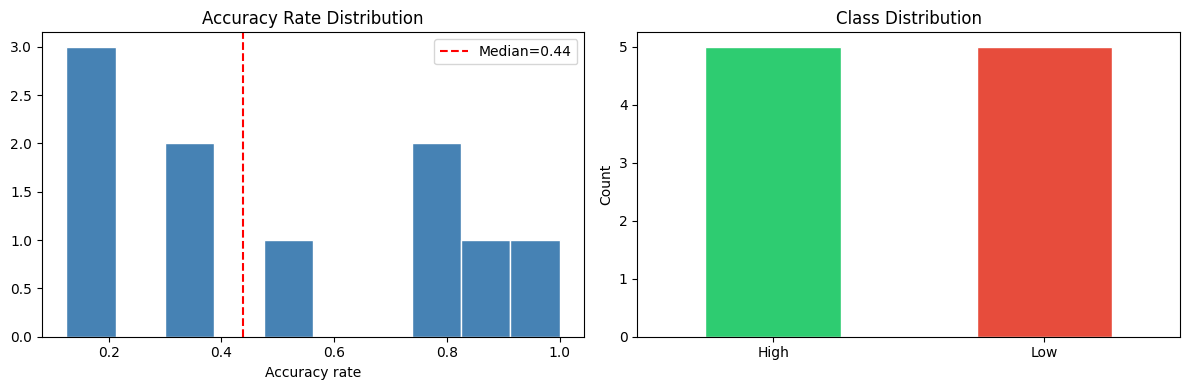

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy histogram
axes[0].hist(responses['accuracy_rate'], bins=10, color='steelblue', edgecolor='white')
axes[0].axvline(median_accuracy, color='red', linestyle='--', label=f'Median={median_accuracy:.2f}')
axes[0].set_title('Accuracy Rate Distribution')
axes[0].set_xlabel('Accuracy rate')
axes[0].legend()

# Label bar chart
label_map = {LABEL_HIGH: 'High', LABEL_LOW: 'Low'}
label_display = responses[PERFORMANCE_LABEL_COL].map(label_map).value_counts()
label_display.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Class Distribution')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/03_label_distribution.png', dpi=150)
plt.show()

## 8. Save labels

In [36]:
output_cols = (['participant_id', 'total_score', 'accuracy_rate',
                PERFORMANCE_LABEL_COL, SPEED_LABEL_COL] +
               correct_cols)

# Add mean_response_time if it exists
if 'mean_response_time_ms' in responses.columns:
    output_cols.append('mean_response_time_ms')

labels_out = responses[[c for c in output_cols if c in responses.columns]]
labels_out.to_csv(LABELS_CSV, index=False)

print(f"Saved: {LABELS_CSV}")
print(f"Shape: {labels_out.shape}")
labels_out.head()

Saved: /home/wlsoo/WID2003/data/processed/labels.csv
Shape: (10, 14)


,participant_id,total_score,accuracy_rate,performance_label,speed_label,findDice_correct,findYummy_correct,frogInBathroom_correct,headphoneInBathroom_correct,frog_correct,whoCheats_correct,whoThief_correct,spotNeedleInst_correct,mean_response_time_ms
0,p003,8,1.000,1,0,1,1,1,1,1,1,1,1,NaN
1,p004,7,0.875,1,0,1,1,0,1,1,1,1,1,NaN
2,p005,6,0.750,1,0,1,0,1,1,1,0,1,1,NaN
3,p006,6,0.750,1,0,1,1,1,0,1,1,0,1,NaN
4,p007,4,0.500,1,0,0,1,0,1,0,1,1,0,NaN
